# Clasificación RT-IoT2022

**Notebook**: limpieza → EDA → modelado → evaluación


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer

# Modelos clásicos
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

%matplotlib inline

## Carga de los datos

In [2]:
train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")
print('Train shape:', train.shape)
print('Test shape:', test.shape)
display(train.head())

Train shape: (92337, 85)
Test shape: (24624, 85)


,id,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,3054,36230,443,tcp,ssl,10.644097,15,10,7,5,...,411331.830867,9.997739e+06,9.997739e+06,9.997739e+06,9.997739e+06,0.0,64240,26544,501,ARP_poisioning
1,3576,57920,443,tcp,ssl,1.250508,13,12,3,9,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,64240,26847,0,Thing_Speak
2,74179,62897,21,tcp,-,0.000002,1,1,1,0,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,64,0,64,DOS_SYN_Hping
3,1011,50078,49186,udp,-,0.000000,1,0,1,0,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0,0,0,NMAP_UDP_SCAN
4,74372,27538,21,tcp,-,0.000002,1,1,1,0,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,64,0,64,DOS_SYN_Hping


## Inspección inicial (concatenado)

In [3]:
df = pd.concat([train,test], ignore_index=True)
print('Combined shape:', df.shape)
display(df.info())
display(df.describe().T)

Combined shape: (116961, 85)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116961 entries, 0 to 116960
Data columns (total 85 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        116961 non-null  int64  
 1   id.orig_p                 116961 non-null  int64  
 2   id.resp_p                 116961 non-null  int64  
 3   proto                     116961 non-null  object 
 4   service                   116961 non-null  object 
 5   flow_duration             116961 non-null  float64
 6   fwd_pkts_tot              116961 non-null  int64  
 7   bwd_pkts_tot              116961 non-null  int64  
 8   fwd_data_pkts_tot         116961 non-null  int64  
 9   bwd_data_pkts_tot         116961 non-null  int64  
 10  fwd_pkts_per_sec          116961 non-null  float64
 11  bwd_pkts_per_sec          116961 non-null  float64
 12  flow_pkts_per_sec         116961 non-null  float64
 13  down_up_ratio  

None

,count,mean,std,min,25%,50%,75%,max
id,116961.0,3.707358e+04,3.047587e+04,0.0,6071.000000,33156.000000,63946.000000,9.465800e+04
id.orig_p,116961.0,3.463689e+04,1.907958e+04,0.0,17689.000000,37222.000000,50975.000000,6.553500e+04
id.resp_p,116961.0,1.010348e+03,5.236931e+03,0.0,21.000000,21.000000,21.000000,6.538900e+04
flow_duration,116961.0,3.875604e+00,1.333311e+02,0.0,0.000001,0.000004,0.000005,2.172834e+04
fwd_pkts_tot,116961.0,2.276750e+00,2.286569e+01,0.0,1.000000,1.000000,1.000000,4.345000e+03
...,...,...,...,...,...,...,...,...
idle.avg,116961.0,1.659357e+06,9.004378e+06,0.0,0.000000,0.000000,0.000000,3.000000e+08
idle.std,116961.0,4.601636e+04,1.085623e+06,0.0,0.000000,0.000000,0.000000,1.208029e+08
fwd_init_window_size,116961.0,6.100190e+03,1.869022e+04,0.0,64.000000,64.000000,64.000000,6.553500e+04
bwd_init_window_size,116961.0,2.736446e+03,1.002846e+04,0.0,0.000000,0.000000,0.000000,6.553500e+04


## Detección de nulos y duplicados (antes de limpieza)

In [4]:
display(df.isnull().sum().sort_values(ascending=False).head(20))
print('Total nulls:', df.isnull().sum().sum())
print('Duplicated rows:', df.duplicated().sum())

id                          0
bwd_iat.std                 0
bwd_subflow_pkts            0
fwd_subflow_pkts            0
payload_bytes_per_second    0
flow_iat.std                0
flow_iat.avg                0
flow_iat.tot                0
flow_iat.max                0
flow_iat.min                0
bwd_iat.avg                 0
flow_pkts_payload.avg       0
bwd_iat.tot                 0
bwd_iat.max                 0
bwd_iat.min                 0
fwd_iat.std                 0
fwd_iat.avg                 0
fwd_iat.tot                 0
fwd_iat.max                 0
fwd_iat.min                 0
dtype: int64

Total nulls: 0
Duplicated rows: 0


## Limpieza del dataset (antes del EDA)

In [5]:
df_clean = df.copy()
threshold = 0.3
cols_to_drop = [c for c in df_clean.columns if df_clean[c].isnull().mean() > threshold]
print('Cols to drop (>30% nulls):', cols_to_drop)
df_clean.drop(columns=cols_to_drop, inplace=True)
# Drop remaining nulls
print('Nulls before dropna:', df_clean.isnull().sum().sum())
df_clean.dropna(inplace=True)
print('Shape after dropna:', df_clean.shape)
# Drop duplicates
print('Duplicates before:', df_clean.duplicated().sum())
df_clean.drop_duplicates(inplace=True)
print('Shape after drop duplicates:', df_clean.shape)
# Ensure Attack_type categorical
if 'Attack_type' in df_clean.columns:
    df_clean['Attack_type'] = df_clean['Attack_type'].astype('category')
# Drop id if exists
if 'id' in df_clean.columns:
    df_clean.drop(columns=['id'], inplace=True)
# Replace inf and dropna
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
df_clean.dropna(inplace=True)
print('Final shape df_clean:', df_clean.shape)

Cols to drop (>30% nulls): []
Nulls before dropna: 0
Shape after dropna: (116961, 85)
Duplicates before: 0
Shape after drop duplicates: (116961, 85)
Final shape df_clean: (116961, 84)


## Estadísticas después de la limpieza

In [6]:
display(df_clean.isnull().sum().sort_values(ascending=False).head(20))
print('Total nulls after:', df_clean.isnull().sum().sum())
print('Duplicates after:', df_clean.duplicated().sum())
display(df_clean.describe().T)
display(df_clean['Attack_type'].value_counts())

id.orig_p                   0
bwd_iat.std                 0
bwd_subflow_pkts            0
fwd_subflow_pkts            0
payload_bytes_per_second    0
flow_iat.std                0
flow_iat.avg                0
flow_iat.tot                0
flow_iat.max                0
flow_iat.min                0
bwd_iat.avg                 0
id.resp_p                   0
bwd_iat.tot                 0
bwd_iat.max                 0
bwd_iat.min                 0
fwd_iat.std                 0
fwd_iat.avg                 0
fwd_iat.tot                 0
fwd_iat.max                 0
fwd_iat.min                 0
dtype: int64

Total nulls after: 0
Duplicates after: 4698


,count,mean,std,min,25%,50%,75%,max
id.orig_p,116961.0,3.463689e+04,1.907958e+04,0.0,17689.000000,37222.000000,50975.000000,6.553500e+04
id.resp_p,116961.0,1.010348e+03,5.236931e+03,0.0,21.000000,21.000000,21.000000,6.538900e+04
flow_duration,116961.0,3.875604e+00,1.333311e+02,0.0,0.000001,0.000004,0.000005,2.172834e+04
fwd_pkts_tot,116961.0,2.276750e+00,2.286569e+01,0.0,1.000000,1.000000,1.000000,4.345000e+03
bwd_pkts_tot,116961.0,1.914707e+00,3.382742e+01,0.0,1.000000,1.000000,1.000000,1.011200e+04
...,...,...,...,...,...,...,...,...
idle.avg,116961.0,1.659357e+06,9.004378e+06,0.0,0.000000,0.000000,0.000000,3.000000e+08
idle.std,116961.0,4.601636e+04,1.085623e+06,0.0,0.000000,0.000000,0.000000,1.208029e+08
fwd_init_window_size,116961.0,6.100190e+03,1.869022e+04,0.0,64.000000,64.000000,64.000000,6.553500e+04
bwd_init_window_size,116961.0,2.736446e+03,1.002846e+04,0.0,0.000000,0.000000,0.000000,6.553500e+04


DOS_SYN_Hping                 89952
Thing_Speak                    7697
ARP_poisioning                 7371
MQTT_Publish                   3911
NMAP_UDP_SCAN                  2462
NMAP_OS_DETECTION              1905
NMAP_XMAS_TREE_SCAN            1904
NMAP_TCP_scan                   947
DDOS_Slowloris                  507
Wipro_bulb                      242
Metasploit_Brute_Force_SSH       36
NMAP_FIN_SCAN                    27
Name: Attack_type, dtype: int64

## EDA: Distribución de clases, histogramas, boxplots y correlación

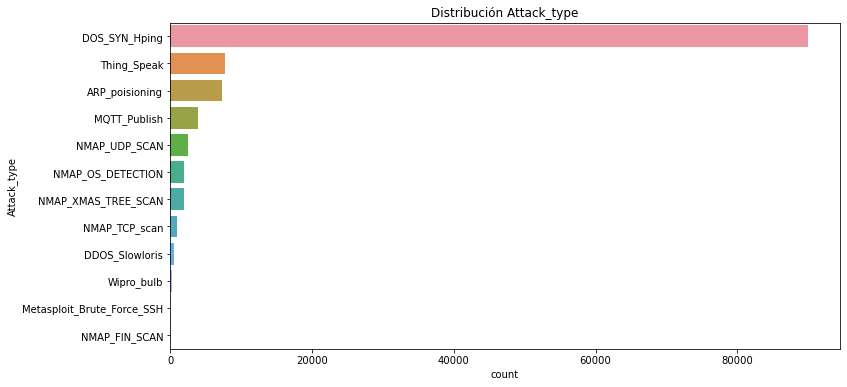

Columns for hist: ['id.orig_p', 'id.resp_p', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot']


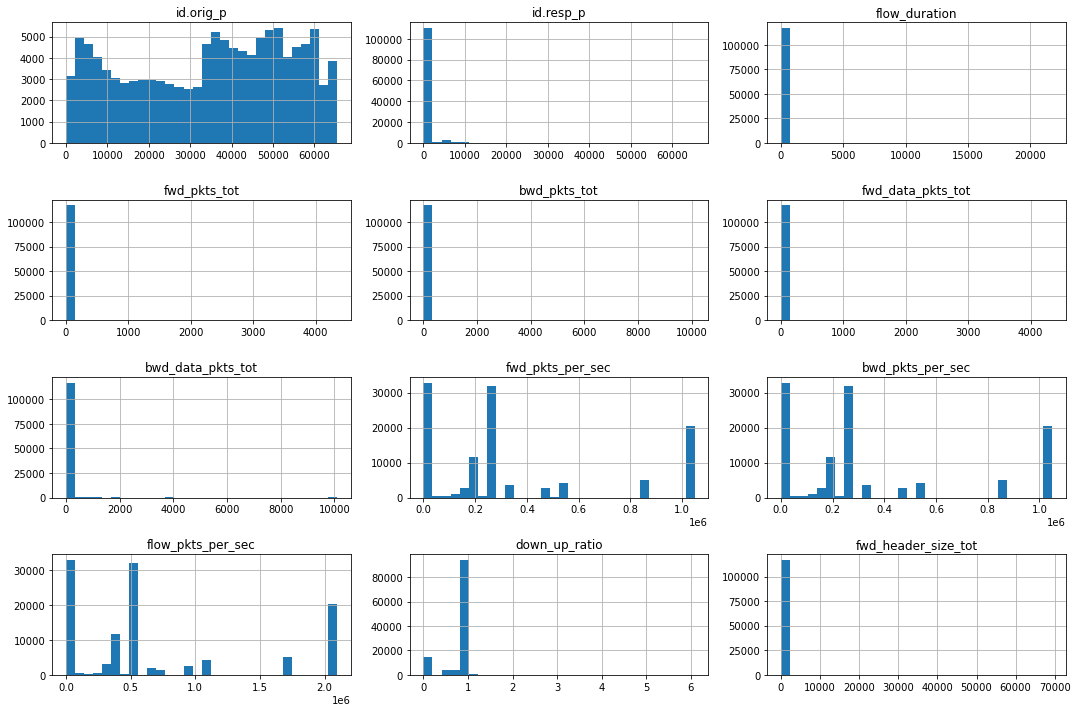

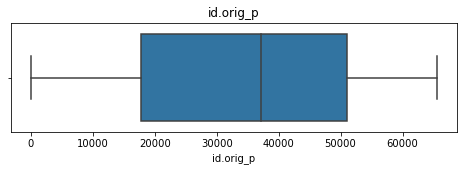

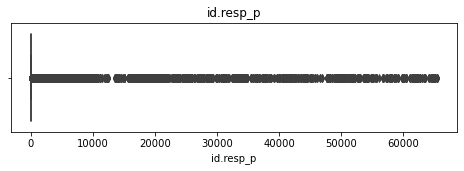

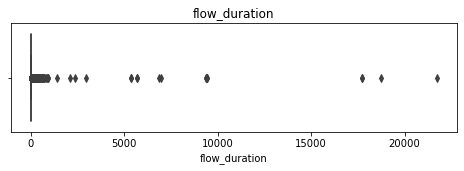

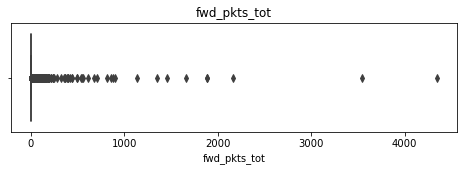

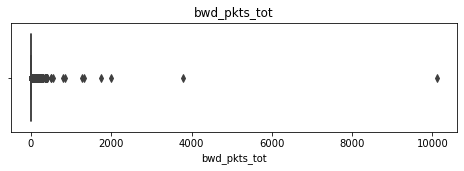

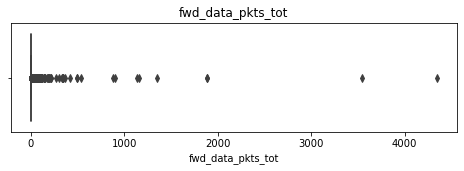

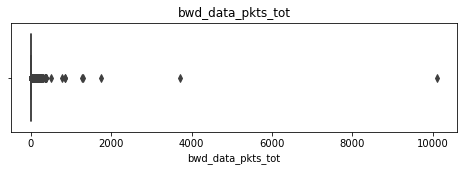

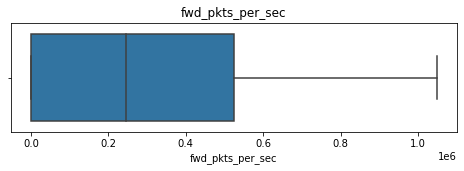

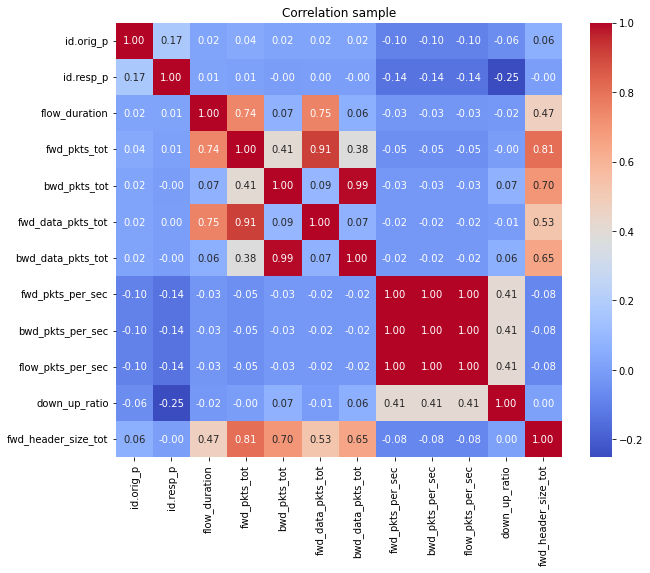

In [7]:
plt.figure(figsize=(12,6))
sns.countplot(y='Attack_type', data=df_clean, order=df_clean['Attack_type'].value_counts().index)
plt.title('Distribución Attack_type')
plt.show()

num_cols = df_clean.select_dtypes(include=['float64','int64']).columns.tolist()
cols_hist = num_cols[:12]
print('Columns for hist:', cols_hist)
df_clean[cols_hist].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

for col in cols_hist[:8]:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df_clean[col])
    plt.title(col)
    plt.show()

corr = df_clean[cols_hist].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation sample')
plt.show()

C:\Users\JULIO TORRES\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


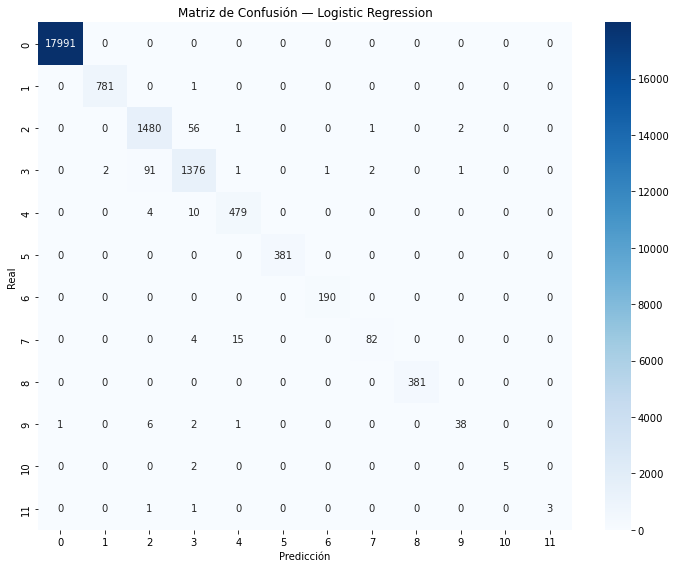

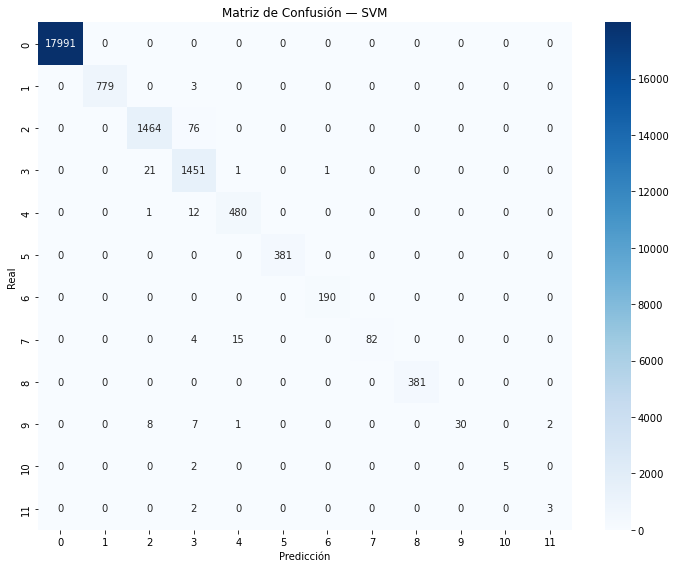

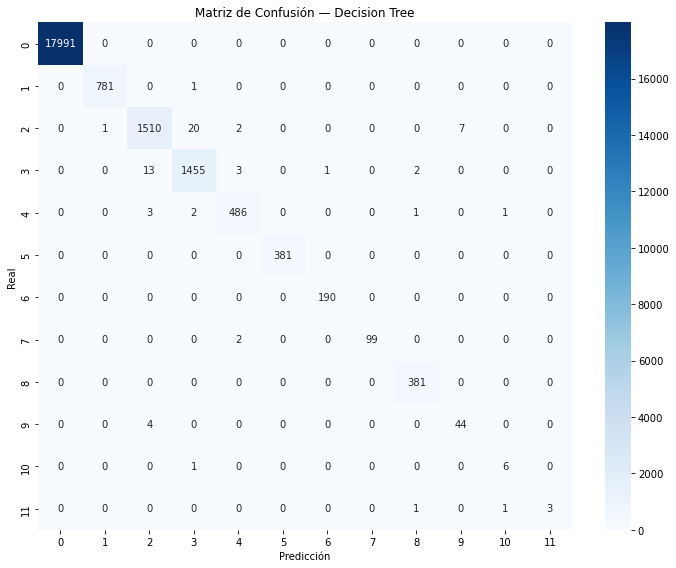

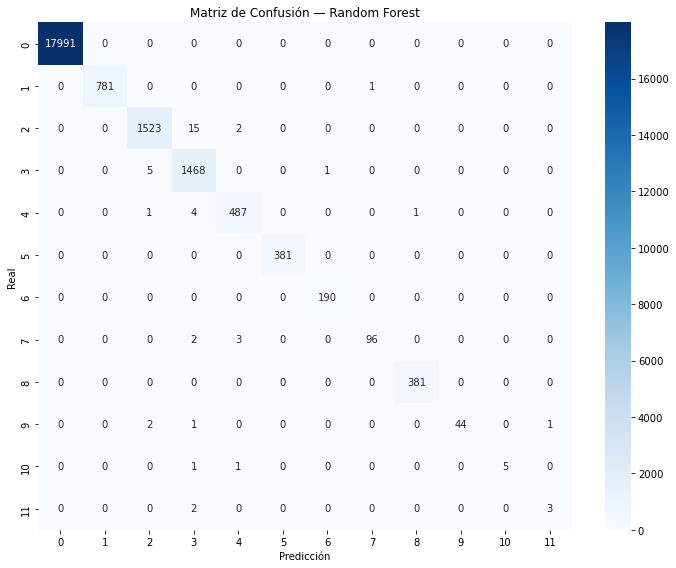

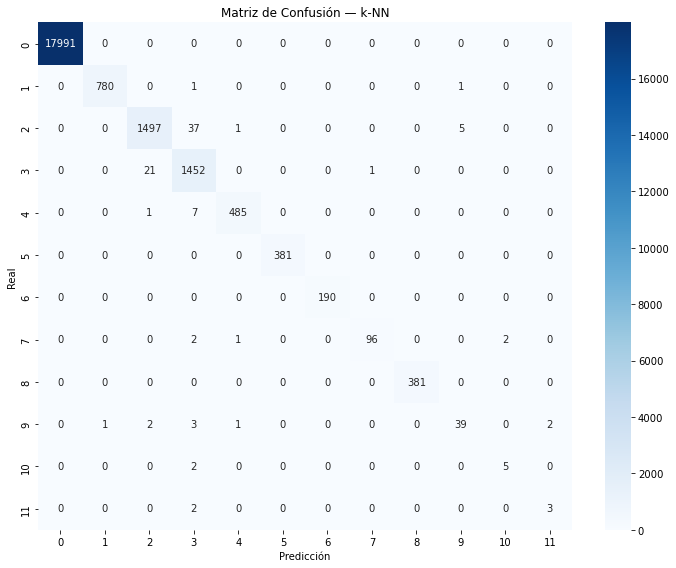

In [13]:
#matrices de confusion
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("confusion_matrices", exist_ok=True)

for nombre, modelo in modelos.items():
    pipe = Pipeline([("preproc", preprocessor), ("clf", modelo)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=y_test.unique())
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de Confusión — {nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.savefig(f"confusion_matrices/cm_{nombre.replace(' ','_')}.png")
    plt.show()

## Preprocesamiento y pipeline

In [8]:
target_col = 'Attack_type'
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()

print('Numeric cols:', len(numeric_cols))
print('Cat cols:', len(cat_cols))

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_cols),
    ('cat', cat_pipeline, cat_cols)
])
print('Preprocessor ready')

Numeric cols: 81
Cat cols: 2
Preprocessor ready


## División train/test

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('X_train', X_train.shape, 'X_test', X_test.shape)
print(y_train.value_counts())

X_train (93568, 83) X_test (23393, 83)
DOS_SYN_Hping                 71961
Thing_Speak                    6157
ARP_poisioning                 5897
MQTT_Publish                   3129
NMAP_UDP_SCAN                  1969
NMAP_OS_DETECTION              1524
NMAP_XMAS_TREE_SCAN            1523
NMAP_TCP_scan                   757
DDOS_Slowloris                  406
Wipro_bulb                      194
Metasploit_Brute_Force_SSH       29
NMAP_FIN_SCAN                    22
Name: Attack_type, dtype: int64


## Entrenamiento de modelos clásicos

In [10]:
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(probability=True),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=150, random_state=42),
    'k-NN': KNeighborsClassifier(n_neighbors=5)
}

resultados = {}
for nombre, modelo in modelos.items():
    print('Training', nombre)
    pipe = Pipeline([('preproc', preprocessor), ('clf', modelo)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print('\nClassification report for', nombre)
    print(classification_report(y_test, y_pred))
    resultados[nombre] = classification_report(y_test, y_pred, output_dict=True)


Training Logistic Regression


C:\Users\JULIO TORRES\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Classification report for Logistic Regression
                            precision    recall  f1-score   support

            ARP_poisioning       0.95      0.93      0.94      1474
            DDOS_Slowloris       0.96      0.81      0.88       101
             DOS_SYN_Hping       1.00      1.00      1.00     17991
              MQTT_Publish       1.00      1.00      1.00       782
Metasploit_Brute_Force_SSH       1.00      0.71      0.83         7
             NMAP_FIN_SCAN       1.00      0.60      0.75         5
         NMAP_OS_DETECTION       1.00      1.00      1.00       381
             NMAP_TCP_scan       0.99      1.00      1.00       190
             NMAP_UDP_SCAN       0.96      0.97      0.97       493
       NMAP_XMAS_TREE_SCAN       1.00      1.00      1.00       381
               Thing_Speak       0.94      0.96      0.95      1540
                Wipro_bulb       0.93      0.79      0.85        48

                  accuracy                           0.99     23393

## Matrices de confusión y comparación de métricas

In [ ]:
metrics = []
for nombre, cr in resultados.items():
    metrics.append({'Modelo': nombre,
                    'Accuracy': cr['accuracy'],
                    'Precision_macro': cr['macro avg']['precision'],
                    'Recall_macro': cr['macro avg']['recall'],
                    'F1_macro': cr['macro avg']['f1-score']})

metrics_df = pd.DataFrame(metrics).set_index('Modelo')
print(metrics_df)

from sklearn.metrics import confusion_matrix
for nombre, modelo in modelos.items():
    pipe = Pipeline([('preproc', preprocessor), ('clf', modelo)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=y_test.cat.categories if hasattr(y_test, 'cat') else np.unique(y_test))
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - ' + nombre)
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

metrics_df.to_csv('metricas_modelos.csv')


                     Accuracy  Precision_macro  Recall_macro  F1_macro
Modelo                                                                
Logistic Regression  0.991194         0.977555      0.898559  0.930895
SVM                  0.993331         0.956033      0.888001  0.915533
Decision Tree        0.997392         0.949450      0.942455  0.938882
Random Forest        0.998162         0.974808      0.929407  0.949240
k-NN                 0.996024         0.925965      0.917971  0.921847


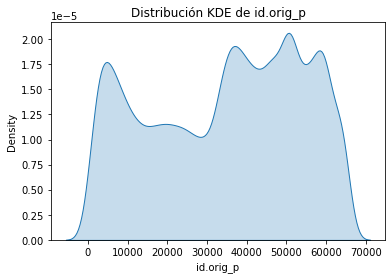

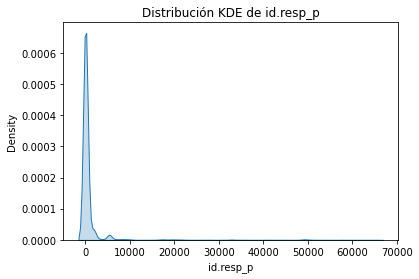

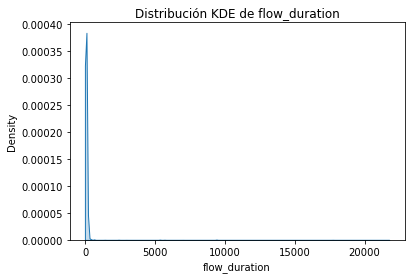

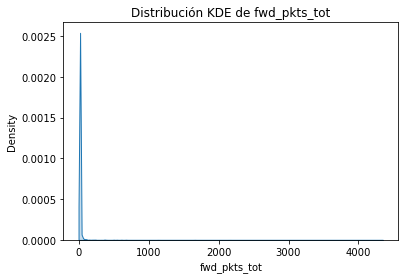

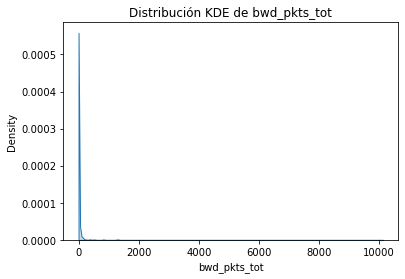

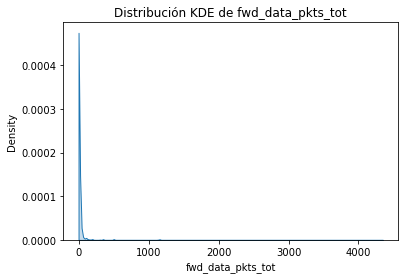

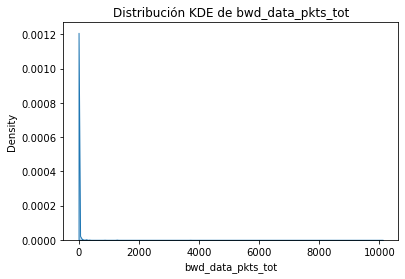

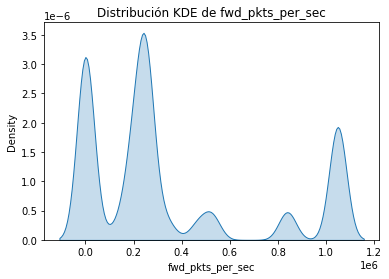

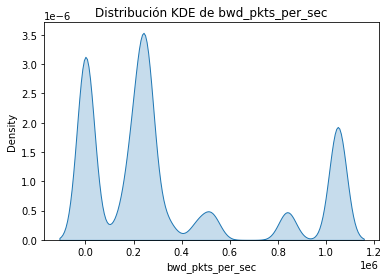

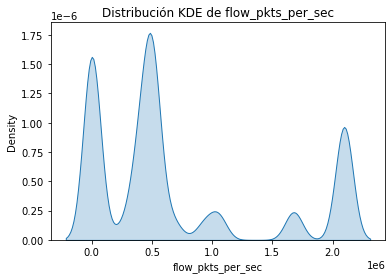

In [14]:
#Distribución de características numéricas (KDE plots)
for col in numeric_cols[:10]:  
    plt.figure(figsize=(6,4))
    sns.kdeplot(df[col], fill=True)
    plt.title(f'Distribución KDE de {col}')
    plt.show()


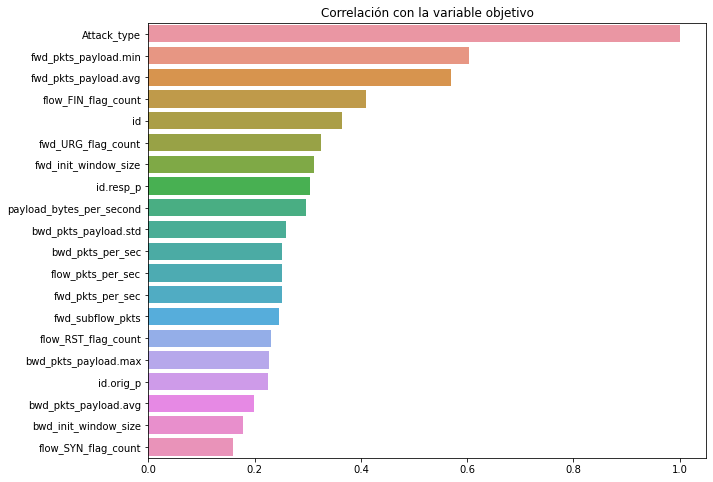

In [17]:
#Gráfico de barras de correlación con la variable objetivo

df["Attack_type"] = df["Attack_type"].astype("category").cat.codes


corr_matrix = df.corr()


corr_target = corr_matrix["Attack_type"].abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,8))
sns.barplot(x=corr_target.values, y=corr_target.index)
plt.title("Correlación con la variable objetivo")
plt.show()


In [18]:
#Outliers por IQRoutliers


numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

outliers = {} 

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    out = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col].count()
    outliers[col] = out

out_df = pd.DataFrame.from_dict(outliers, orient="index", columns=["outliers"]).sort_values("outliers", ascending=False)

out_df


,outliers
flow_pkts_payload.avg,36201
bwd_header_size_tot,31484
bwd_header_size_max,31474
flow_ACK_flag_count,31422
bwd_pkts_tot,30739
...,...
bwd_URG_flag_count,0
payload_bytes_per_second,0
flow_pkts_per_sec,0
id.orig_p,0
